# Traffic Forecasting

This notebook is a beginner-friendly project workflow for predicting traffic volume.

We will:
1. load the traffic dataset
2. clean and prepare the data
3. create useful time-based features
4. train and compare prediction models
5. save the best model for later use


In [1]:
from pathlib import Path
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

warnings.filterwarnings('ignore')

PROJECT_DIR = Path.cwd().resolve()
MODELS_DIR = PROJECT_DIR.parent / 'models'
OUTPUTS_DIR = PROJECT_DIR.parent / 'outputs'
MODELS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

print('Project setup complete. We are ready to work with the traffic data.')


Project setup complete. We are ready to work with the traffic data.


## Step 2: Load the traffic dataset

The dataset is already present in the project folder. We will read it and check the columns before training any model.


In [2]:
traffic_path = '../data/traffic/Metro_Interstate_Traffic_Volume.csv'
df = pd.read_csv(traffic_path)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print(df.head(10))
print(df.isnull().sum())
print(df.describe())

Shape: (48204, 9)
Columns: ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   
5     NaN  291.72      0.0      0.0           1        Clear   
6     NaN  293.17      0.0      0.0           1        Clear   
7     NaN  293.86      0.0      0.0           1        Clear   
8     NaN  294.14      0.0      0.0          20       Clouds   
9     NaN  293.10      0.0      0.0          20       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken cloud

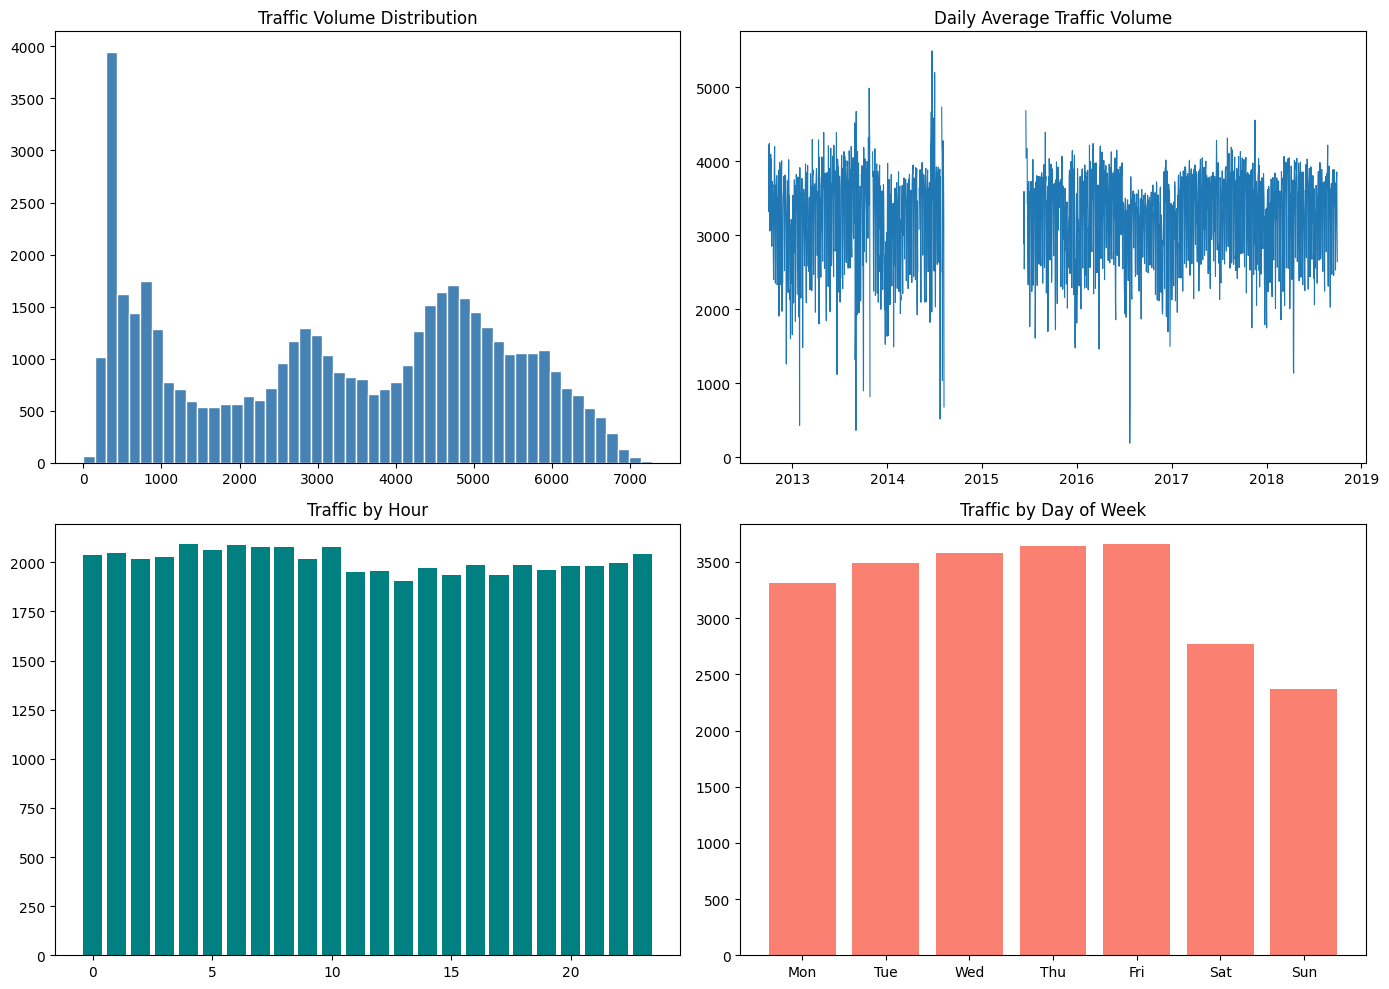

In [3]:
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values('date_time').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(df['traffic_volume'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Traffic Volume Distribution')
axes[0, 1].plot(df.set_index('date_time')['traffic_volume'].resample('D').mean(), linewidth=0.8)
axes[0, 1].set_title('Daily Average Traffic Volume')
axes[1, 0].bar(df['date_time'].dt.hour.value_counts().sort_index().index, df['date_time'].dt.hour.value_counts().sort_index().values, color='teal')
axes[1, 0].set_title('Traffic by Hour')
axes[1, 1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], df.groupby(df['date_time'].dt.dayofweek)['traffic_volume'].mean().values, color='salmon')
axes[1, 1].set_title('Traffic by Day of Week')
plt.tight_layout()
plt.savefig('../outputs/traffic_eda.png', dpi=100)
plt.show()

In [4]:
df = df.drop_duplicates()
df = df.dropna(subset=['traffic_volume'])
df[['temp','rain_1h','snow_1h','clouds_all']] = df[['temp','rain_1h','snow_1h','clouds_all']].fillna(df[['temp','rain_1h','snow_1h','clouds_all']].median())

df['year'] = df['date_time'].dt.year
df['month'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['weekend'] = (df['day_of_week'] >= 5).astype(int)

le_holiday = LabelEncoder()
le_weather_main = LabelEncoder()
le_weather_desc = LabelEncoder()
df['holiday_enc'] = le_holiday.fit_transform(df['holiday'].astype(str))
df['weather_main_enc'] = le_weather_main.fit_transform(df['weather_main'].astype(str))
df['weather_desc_enc'] = le_weather_desc.fit_transform(df['weather_description'].astype(str))

for lag in [1, 2, 3, 6, 12, 24]:
    df[f'traffic_lag_{lag}'] = df['traffic_volume'].shift(lag)

df['rolling_mean_3'] = df['traffic_volume'].shift(1).rolling(3, min_periods=1).mean()
df['rolling_mean_6'] = df['traffic_volume'].shift(1).rolling(6, min_periods=1).mean()
df['rolling_mean_12'] = df['traffic_volume'].shift(1).rolling(12, min_periods=1).mean()
df['rolling_std_6'] = df['traffic_volume'].shift(1).rolling(6, min_periods=1).std().fillna(0)

print('Shape after preprocessing:', df.shape)
print(df.head())

Shape after preprocessing: (48187, 28)
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description           date_time  traffic_volume  year  ...  \
0    scattered clouds 2012-10-02 09:00:00            5545  2012  ...   
1       broken clouds 2012-10-02 10:00:00            4516  2012  ...   
2     overcast clouds 2012-10-02 11:00:00            4767  2012  ...   
3     overcast clouds 2012-10-02 12:00:00            5026  2012  ...   
4       broken clouds 2012-10-02 13:00:00            4918  2012  ...   

   traffic_lag_1  traffic_lag_2  traffic_lag_3  traffic_lag_6  traffic_lag_12  \
0            NaN            NaN            NaN            NaN 

In [5]:
df['target'] = df['traffic_volume'].shift(-1)
df = df.dropna(subset=['target'] + [f'traffic_lag_{l}' for l in [1, 2, 3, 6, 12, 24]])
df = df.reset_index(drop=True)
print('Shape after target creation:', df.shape)
print(df[['date_time', 'traffic_volume', 'target']].head())

Shape after target creation: (48162, 29)
            date_time  traffic_volume  target
0 2012-10-03 12:00:00            5097  4887.0
1 2012-10-03 13:00:00            4887  5337.0
2 2012-10-03 14:00:00            5337  5692.0
3 2012-10-03 15:00:00            5692  6137.0
4 2012-10-03 16:00:00            6137  4623.0


In [6]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)
train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

print('Train:', len(train))
print('Validation:', len(val))
print('Test:', len(test))

Train: 33713
Validation: 7224
Test: 7225


In [7]:
FEATURES = [
    'hour', 'day_of_week', 'month', 'weekend',
    'holiday_enc', 'temp', 'rain_1h', 'snow_1h', 'clouds_all',
    'weather_main_enc', 'weather_desc_enc',
    'traffic_lag_1', 'traffic_lag_2', 'traffic_lag_3',
    'traffic_lag_6', 'traffic_lag_12', 'traffic_lag_24',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12', 'rolling_std_6'
]
TARGET = 'target'

X_train, y_train = train[FEATURES], train[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(X_train.shape, X_val.shape, X_test.shape)

(33713, 21) (7224, 21) (7225, 21)


In [8]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name:30s} | MAE: {mae:7.1f} | RMSE: {rmse:7.1f} | R2: {r2:.4f}')
    return {'model': name, 'MAE': round(mae, 1), 'RMSE': round(rmse, 1), 'R2': round(r2, 4)}

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

results = []
results.append(evaluate('Linear Regression', y_test, lr_pred))
results.append(evaluate('Random Forest', y_test, rf_pred))

print(pd.DataFrame(results).to_string(index=False))

Linear Regression              | MAE:   731.5 | RMSE:   952.5 | R2: 0.7697
Random Forest                  | MAE:   242.9 | RMSE:   382.2 | R2: 0.9629
            model   MAE  RMSE     R2
Linear Regression 731.5 952.5 0.7697
    Random Forest 242.9 382.2 0.9629


In [9]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse',
    verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_pred = xgb_model.predict(X_test)
results.append(evaluate('XGBoost', y_test, xgb_pred))

print(pd.DataFrame(results).to_string(index=False))

XGBoost                        | MAE:   248.5 | RMSE:   385.9 | R2: 0.9622
            model   MAE  RMSE     R2
Linear Regression 731.5 952.5 0.7697
    Random Forest 242.9 382.2 0.9629
          XGBoost 248.5 385.9 0.9622


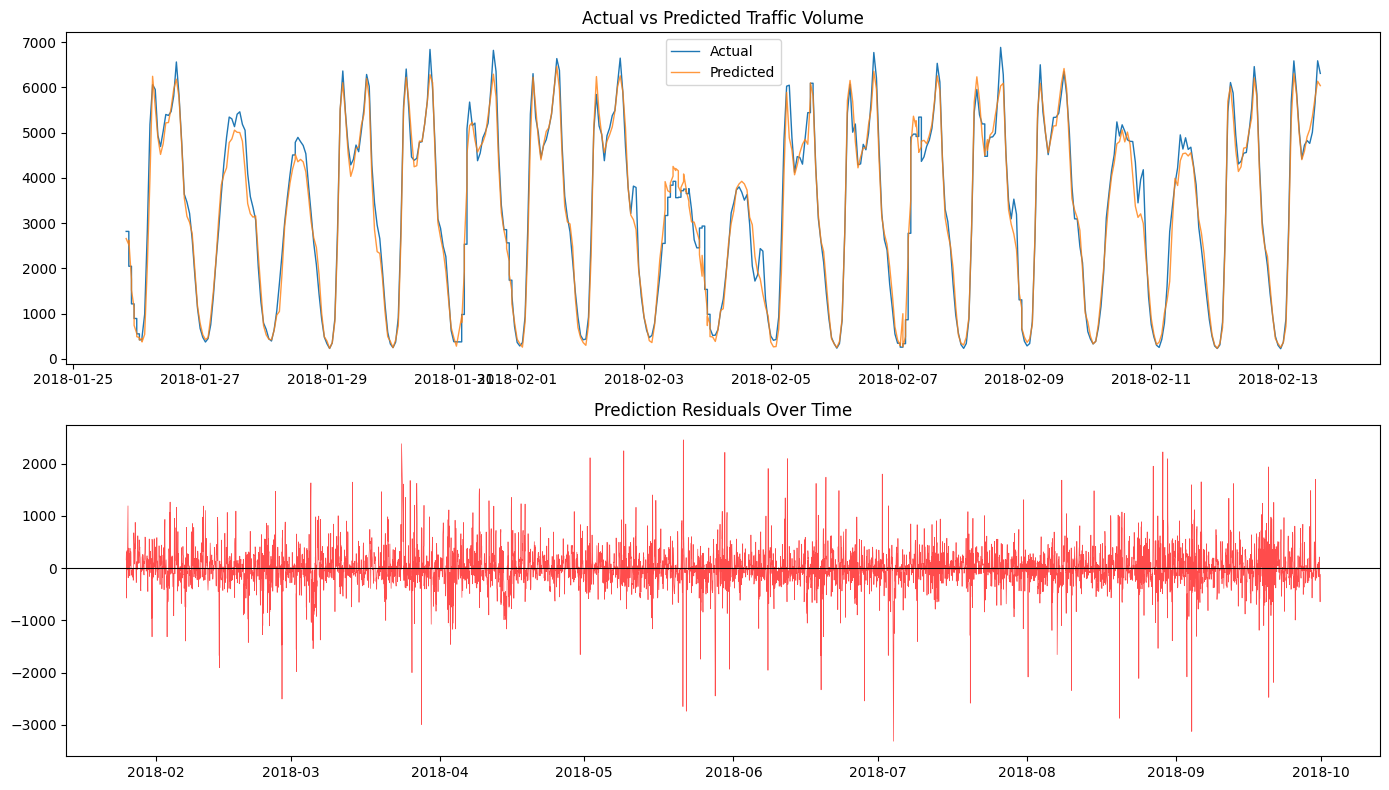

In [10]:
test_dates = test['date_time'].values
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(test_dates[:500], y_test.values[:500], label='Actual', linewidth=1)
axes[0].plot(test_dates[:500], xgb_pred[:500], label='Predicted', linewidth=1, alpha=0.8)
axes[0].set_title('Actual vs Predicted Traffic Volume')
axes[0].legend()
residuals = y_test.values - xgb_pred
axes[1].plot(test_dates, residuals, linewidth=0.5, color='red', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Prediction Residuals Over Time')
plt.tight_layout()
plt.savefig('../outputs/traffic_predictions.png', dpi=100)
plt.show()

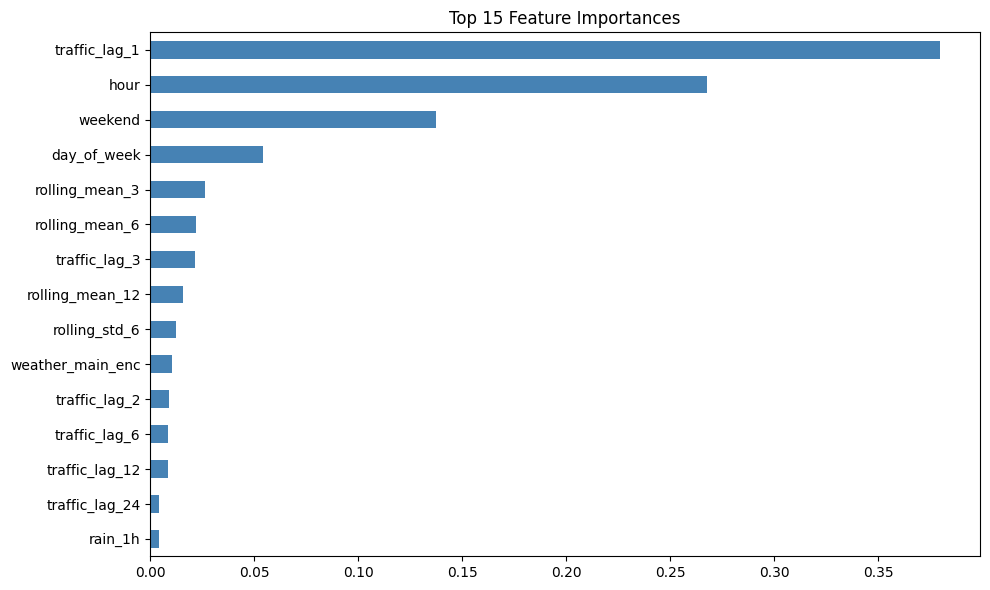

traffic_lag_1     0.380007
hour              0.267794
weekend           0.137606
day_of_week       0.054310
rolling_mean_3    0.026190
dtype: float32


In [11]:
importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importance.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/traffic_feature_importance.png', dpi=100)
plt.show()
print(importance.head(5))

In [12]:
joblib.dump(xgb_model, '../models/traffic_forecasting_model.pkl')
joblib.dump(FEATURES, '../models/traffic_features.pkl')
joblib.dump({'holiday': le_holiday, 'weather_main': le_weather_main, 'weather_desc': le_weather_desc}, '../models/traffic_encoders.pkl')
print('Traffic model saved.')

Traffic model saved.


## Notes
This model is the first part of the modular urban AI system. It predicts traffic volume using recent temporal and weather patterns while keeping this as a separate forecasting problem from energy and anomaly detection.